In [1]:
import os
import pandas as pd

In [2]:
df = pd.read_csv('./train.csv')
# Print basic information about the dataset
print("Dataset Shape:")
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")
print("\n" + "="*50)

# Display first few rows
print("First 5 rows:")
print(df.head())
print("\n" + "="*50)

# Display basic info about the dataframe
print("Dataset Info:")
print(df.info())
print("\n" + "="*50)

# Display statistical summary
print("Statistical Summary:")
print(df.describe())
print("\n" + "="*50)

# Check for missing values
print("Missing Values:")
print(df.isnull().sum())
print("\n" + "="*50)

# Display column names and data types
print("Columns and Data Types:")
for col in df.columns:
    print(f"{col}: {df[col].dtype}")

Dataset Shape:
Rows: 59904, Columns: 88

First 5 rows:
   Unnamed: 0                                    id  sex  age  innet_dura  \
0           1  738f9d93-b51b-47c9-97f0-590527042013    1   34          17   
1           2  b0384a6e-0330-4e8f-a13e-b59acfcca5ad    1   37         132   
2           3  90631d89-e5f0-46eb-afd3-ac104f830fa1    1   41          35   
3           4  6dc8992e-5f5f-4f4b-90e6-cd1b00038928    1   34          91   
4           5  3ecaed5b-abd4-4a7e-9620-ee8441adc124    2   27         129   

    arpu  l3m_avg_mou  l3m_avg_dou  l3m_avg_bill_dura  cm_tot_bill_dura  ...  \
0   84.5    1049.0000     412.5410                0.0                 0  ...   
1  172.0     210.6667   25779.4310                0.0                 0  ...   
2  116.0      83.6667   14559.4574                0.0                 0  ...   
3  158.0     128.0000   34731.8750                0.0                 0  ...   
4   99.0      44.0000   29129.3919                0.0                 0  ...   

 

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Select only numeric columns for correlation analysis
numeric_columns = df.select_dtypes(include=[np.number]).columns.tolist()
print(f"Numeric columns found: {len(numeric_columns)}")
print("Numeric columns:", numeric_columns[:10], "...")  # Show first 10

# Calculate correlation matrix for numeric columns only
correlation_matrix = df[numeric_columns].corr()

# Get correlations with the target label
label_correlations = correlation_matrix['label'].sort_values(ascending=False)
print("\nCorrelation with Label (sorted):")
print(label_correlations)

Numeric columns found: 87
Numeric columns: ['Unnamed: 0', 'sex', 'age', 'innet_dura', 'arpu', 'l3m_avg_mou', 'l3m_avg_dou', 'l3m_avg_bill_dura', 'cm_tot_bill_dura', 'cm_local_voice_dura'] ...

Correlation with Label (sorted):
label                    1.000000
arpu                     0.348964
is_bd_tv                 0.148115
gprs_days                0.127634
l3m_avg_mou              0.094834
                           ...   
innet_dura              -0.036654
read_usr_lbl            -0.038246
is_bd_status_abnormal   -0.078128
fashion_time_m                NaN
hi_flux_usr_lbl               NaN
Name: label, Length: 87, dtype: float64


In [4]:
# 1. Basic correlation analysis with numeric data only
def analyze_correlations(df):
    # Select numeric columns
    numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    
    # Calculate correlation matrix
    corr_matrix = df[numeric_cols].corr()
    
    # Get correlations with label
    label_corr = corr_matrix['label'].drop('label').sort_values(key=abs, ascending=False)
    
    return corr_matrix, label_corr, numeric_cols

# Run the analysis
corr_matrix, label_correlations, numeric_cols = analyze_correlations(df)

print("Top 15 features most correlated with label:")
print(label_correlations.head(15))
print("\nTop 15 features least correlated with label:")
print(label_correlations.tail(15))

Top 15 features most correlated with label:
arpu                     0.348964
is_bd_tv                 0.148115
gprs_days                0.127634
l3m_avg_mou              0.094834
term_cont_mon            0.087319
cm_local_voice_dura      0.087294
is_bd_status_abnormal   -0.078128
term_cont_dfee           0.074877
open_day_m               0.072893
is_10g_pon               0.072071
watch_times_m            0.062024
login_times_m            0.060022
click_day_m              0.053700
user_duration_m          0.048385
cm_base_plan_flux_use    0.043815
Name: label, dtype: float64

Top 15 features least correlated with label:
travel_cnt_m             0.003607
read_time_m             -0.003090
edu_cnt_m                0.003053
if_like_games_cust       0.002350
anchor_dayt_use_dur     -0.001622
travel_time_m            0.001531
cm_chos_plan_flux_use   -0.001008
is_ent_vnet_user         0.000772
bd_cnt_m                 0.000724
edu_time_m              -0.000628
anchor_use_dur          -0.00045

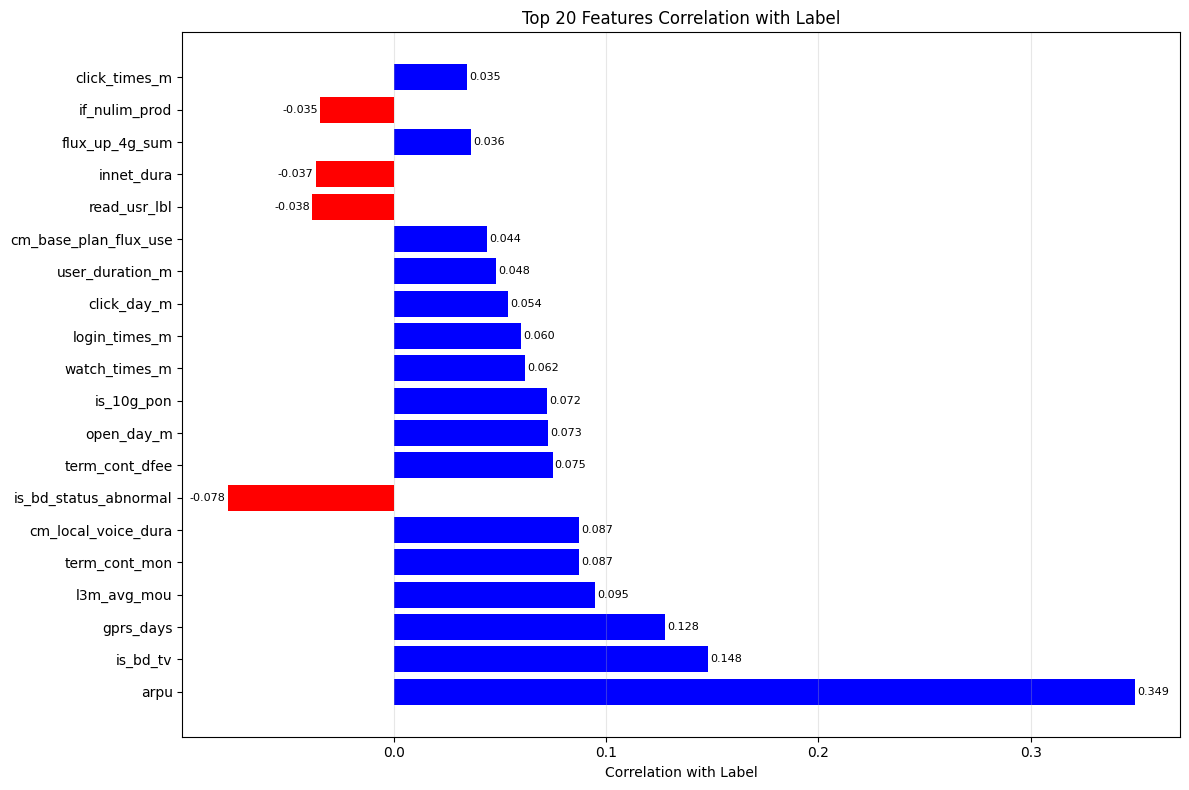

Missing values summary:
long_vid_ngt_use_dur     47451
gm_use_dur               47451
long_vid_dayt_use_dur    47451
long_vid_use_dur         47451
shrt_vid_ngt_use_dur     47451
shrt_vid_dayt_use_dur    47451
shrt_vid_use_dur         47451
sev_vid_usr_lbl          47451
liv_usr_lbl              47451
netdisk_usr_lbl          47451
vid_usr_lbl              47451
read_usr_lbl             47451
netdisk_dayt_use_dur     47451
netdisk_ngt_use_dur      47451
hi_flux_usr_lbl          47451
msc_usr_lbl              47451
gm_usr_lbl               47451
anchor_dayt_use_dur      47451
netdisk_use_dur          47451
wtch_liv_ngt_use_dur     47451
wtch_liv_dayt_use_dur    47451
wtch_liv_use_dur         47451
anchor_ngt_use_dur       47451
gm_ngt_use_dur           47451
gm_dayt_use_dur          47451
anchor_use_dur           47451
dtype: int64

Total samples: 59904
Complete cases: 12453

Top correlations using pairwise complete observations:
arpu                     0.348964
is_bd_tv               

In [5]:
# 2. Visualize top correlations with label
plt.figure(figsize=(12, 8))
top_corr = label_correlations.head(20)
colors = ['red' if x < 0 else 'blue' for x in top_corr.values]
bars = plt.barh(range(len(top_corr)), top_corr.values, color=colors)
plt.yticks(range(len(top_corr)), top_corr.index, fontsize=10)
plt.xlabel('Correlation with Label')
plt.title('Top 20 Features Correlation with Label')
plt.grid(axis='x', alpha=0.3)

# Add value labels on bars
for i, (bar, val) in enumerate(zip(bars, top_corr.values)):
    plt.text(val + 0.001 if val >= 0 else val - 0.001, i, f'{val:.3f}', 
             va='center', ha='left' if val >= 0 else 'right', fontsize=8)

plt.tight_layout()
plt.show()

# 3. Handle missing values and recalculate correlations
print("Missing values summary:")
missing_summary = df[numeric_cols].isnull().sum().sort_values(ascending=False)
print(missing_summary[missing_summary > 0])

# Option 1: Use pairwise correlations (handles missing values automatically)
print(f"\nTotal samples: {len(df)}")
print(f"Complete cases: {len(df.dropna())}")

# Calculate pairwise correlations (default behavior)
pairwise_corr = df[numeric_cols].corr()['label'].drop('label').sort_values(key=abs, ascending=False)
print("\nTop correlations using pairwise complete observations:")
print(pairwise_corr.head(15))

Top 15 correlations with statistical info:
                  feature  correlation        p_value  sample_size  \
4                    arpu     0.348964   0.000000e+00        59904   
32               is_bd_tv     0.148115  6.370375e-291        59904   
24              gprs_days     0.127634  5.812284e-216        59904   
5             l3m_avg_mou     0.094834  1.054375e-119        59904   
39          term_cont_mon     0.087319  1.031823e-101        59904   
9     cm_local_voice_dura     0.087294  1.177303e-101        59904   
27  is_bd_status_abnormal    -0.078128   9.501095e-82        59904   
40         term_cont_dfee     0.074877   3.193742e-75        59904   
37             open_day_m     0.072893   2.243082e-71        59904   
28             is_10g_pon     0.072071   8.182242e-70        59904   
36          watch_times_m     0.062024   3.822132e-52        59904   
34          login_times_m     0.060022   6.122605e-49        59904   
38            click_day_m     0.053700   1.6479

/tmp/ipykernel_2210059/1056176214.py:15: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  corr, p_value = pearsonr(valid_data[col], valid_data[target_col])
/tmp/ipykernel_2210059/1056176214.py:15: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  corr, p_value = pearsonr(valid_data[col], valid_data[target_col])


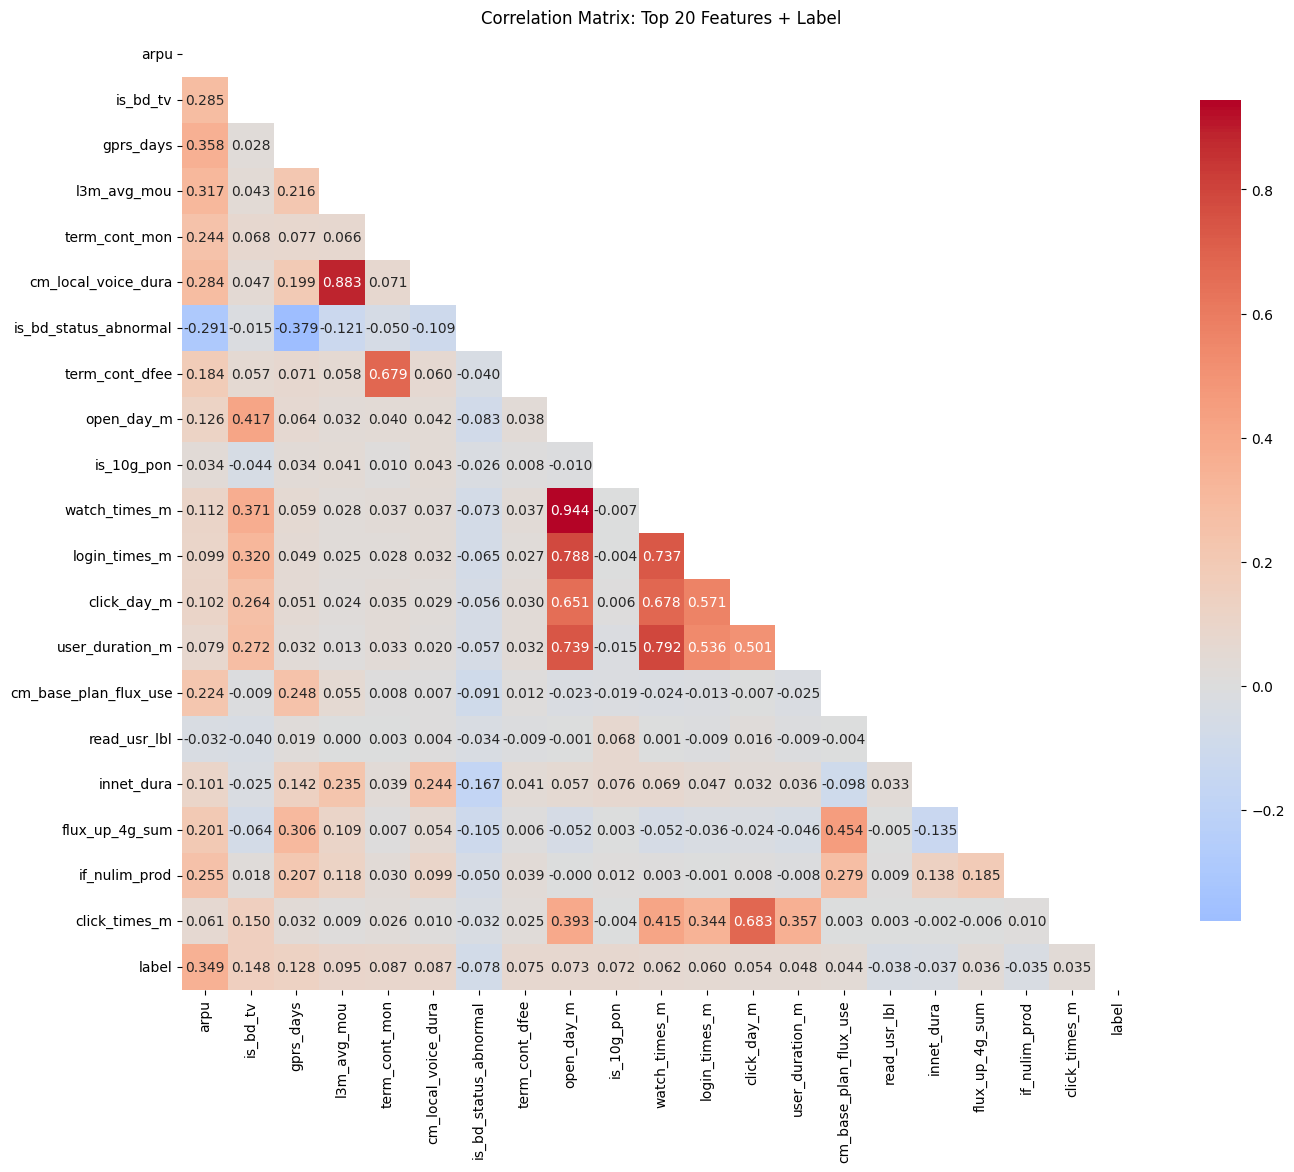

In [6]:
# 4. Statistical significance testing
from scipy.stats import pearsonr

def correlation_with_significance(df, target_col='label'):
    numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    correlations = []
    
    for col in numeric_cols:
        if col != target_col:
            # Get valid pairs (non-missing)
            valid_data = df[[col, target_col]].dropna()
            
            if len(valid_data) > 10:  # Minimum sample size
                try:
                    corr, p_value = pearsonr(valid_data[col], valid_data[target_col])
                    correlations.append({
                        'feature': col,
                        'correlation': corr,
                        'p_value': p_value,
                        'abs_correlation': abs(corr),
                        'sample_size': len(valid_data),
                        'missing_pct': (len(df) - len(valid_data)) / len(df) * 100
                    })
                except:
                    continue
    
    # Convert to DataFrame and sort
    corr_df = pd.DataFrame(correlations)
    corr_df = corr_df.sort_values('abs_correlation', ascending=False)
    
    return corr_df

# Get correlations with significance
corr_results = correlation_with_significance(df)
print("Top 15 correlations with statistical info:")
print(corr_results.head(15)[['feature', 'correlation', 'p_value', 'sample_size', 'missing_pct']])

# Filter for significant correlations
significant_corr = corr_results[corr_results['p_value'] < 0.05]
print(f"\nStatistically significant correlations (p < 0.05): {len(significant_corr)}")
print("\nTop 10 significant correlations:")
print(significant_corr.head(10)[['feature', 'correlation', 'p_value']])

# 5. Visualize correlation heatmap for top features
top_features = corr_results.head(20)['feature'].tolist() + ['label']
subset_corr = df[top_features].corr()

plt.figure(figsize=(14, 12))
mask = np.triu(np.ones_like(subset_corr, dtype=bool))  # Mask upper triangle
sns.heatmap(subset_corr, mask=mask, annot=True, cmap='coolwarm', center=0,
            square=True, fmt='.3f', cbar_kws={"shrink": .8})
plt.title('Correlation Matrix: Top 20 Features + Label')
plt.tight_layout()
plt.show()

Missing data analysis:
Columns with missing data: 26
gm_use_dur: Label 0 missing: 79.3%, Label 1 missing: 79.0%
gm_dayt_use_dur: Label 0 missing: 79.3%, Label 1 missing: 79.0%
gm_ngt_use_dur: Label 0 missing: 79.3%, Label 1 missing: 79.0%
shrt_vid_use_dur: Label 0 missing: 79.3%, Label 1 missing: 79.0%
shrt_vid_dayt_use_dur: Label 0 missing: 79.3%, Label 1 missing: 79.0%
shrt_vid_ngt_use_dur: Label 0 missing: 79.3%, Label 1 missing: 79.0%
long_vid_use_dur: Label 0 missing: 79.3%, Label 1 missing: 79.0%
long_vid_dayt_use_dur: Label 0 missing: 79.3%, Label 1 missing: 79.0%
long_vid_ngt_use_dur: Label 0 missing: 79.3%, Label 1 missing: 79.0%
anchor_use_dur: Label 0 missing: 79.3%, Label 1 missing: 79.0%
Top 15 features by Random Forest importance:
                feature  importance
4                  arpu    0.121608
3            innet_dura    0.041121
19    cm_base_plan_flux    0.038034
18      cm_flux_tot_cnt    0.037465
29            bd_flux_m    0.032808
5           l3m_avg_mou    0.

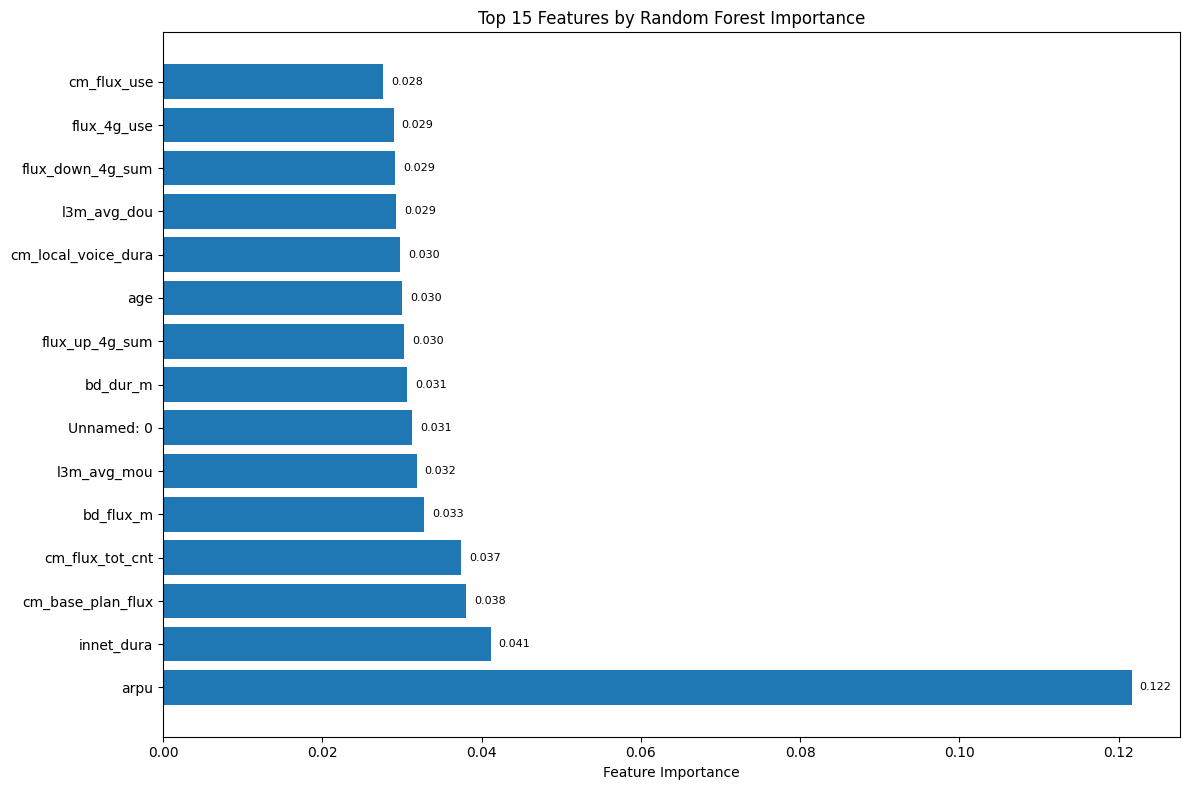


Model Accuracy: 0.797

Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.94      0.87      8981
           1       0.68      0.36      0.47      3000

    accuracy                           0.80     11981
   macro avg       0.75      0.65      0.67     11981
weighted avg       0.78      0.80      0.77     11981



In [7]:
# 6. Analyze missing data patterns
def analyze_missing_patterns(df):
    missing_cols = df.columns[df.isnull().any()].tolist()
    
    if len(missing_cols) > 0:
        print("Missing data analysis:")
        print(f"Columns with missing data: {len(missing_cols)}")
        
        # Check if missing data is related to label
        for col in missing_cols[:10]:  # Check first 10 missing columns
            missing_mask = df[col].isnull()
            if missing_mask.sum() > 0:
                label_0_missing = missing_mask[df['label'] == 0].mean()
                label_1_missing = missing_mask[df['label'] == 1].mean()
                print(f"{col}: Label 0 missing: {label_0_missing:.1%}, Label 1 missing: {label_1_missing:.1%}")

analyze_missing_patterns(df)

# 7. Feature importance using Random Forest (handles missing values)
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

# Prepare data - fill missing values with median for numeric columns
X = df[numeric_cols].copy()
X = X.drop('label', axis=1)  # Remove target
X_filled = X.fillna(X.median())  # Fill with median
y = df['label']

# Split data
X_train, X_test, y_train, y_test = train_test_split(X_filled, y, test_size=0.2, random_state=42, stratify=y)

# Train Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

# Get feature importance
importance_df = pd.DataFrame({
    'feature': X_filled.columns,
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=False)

print("Top 15 features by Random Forest importance:")
print(importance_df.head(15))

# Visualize feature importance
plt.figure(figsize=(12, 8))
top_importance = importance_df.head(15)
bars = plt.barh(range(len(top_importance)), top_importance['importance'])
plt.yticks(range(len(top_importance)), top_importance['feature'])
plt.xlabel('Feature Importance')
plt.title('Top 15 Features by Random Forest Importance')

# Add value labels
for i, (bar, val) in enumerate(zip(bars, top_importance['importance'])):
    plt.text(val + 0.001, i, f'{val:.3f}', va='center', ha='left', fontsize=8)

plt.tight_layout()
plt.show()

# Model performance
from sklearn.metrics import classification_report, accuracy_score
y_pred = rf.predict(X_test)
print(f"\nModel Accuracy: {accuracy_score(y_test, y_pred):.3f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Preparing data...
Class distribution in training: [30534 10200]
Class weights: [0.73255192 1.26744808]
Using device: cuda

Model Architecture:
AttentionClassifier(
  (input_bn): BatchNorm1d(86, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (feature_transform): Sequential(
    (0): Linear(in_features=86, out_features=256, bias=True)
    (1): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.4, inplace=False)
  )
  (query): Linear(in_features=256, out_features=256, bias=True)
  (key): Linear(in_features=256, out_features=256, bias=True)
  (value): Linear(in_features=256, out_features=256, bias=True)
  (feature_attention): Sequential(
    (0): Linear(in_features=86, out_features=128, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.4, inplace=False)
    (3): Linear(in_features=128, out_features=86, bias=True)
    (4): Sigmoid()
  )
  (network): Sequential(
    (0): Linear(in_features=256, out_features=2

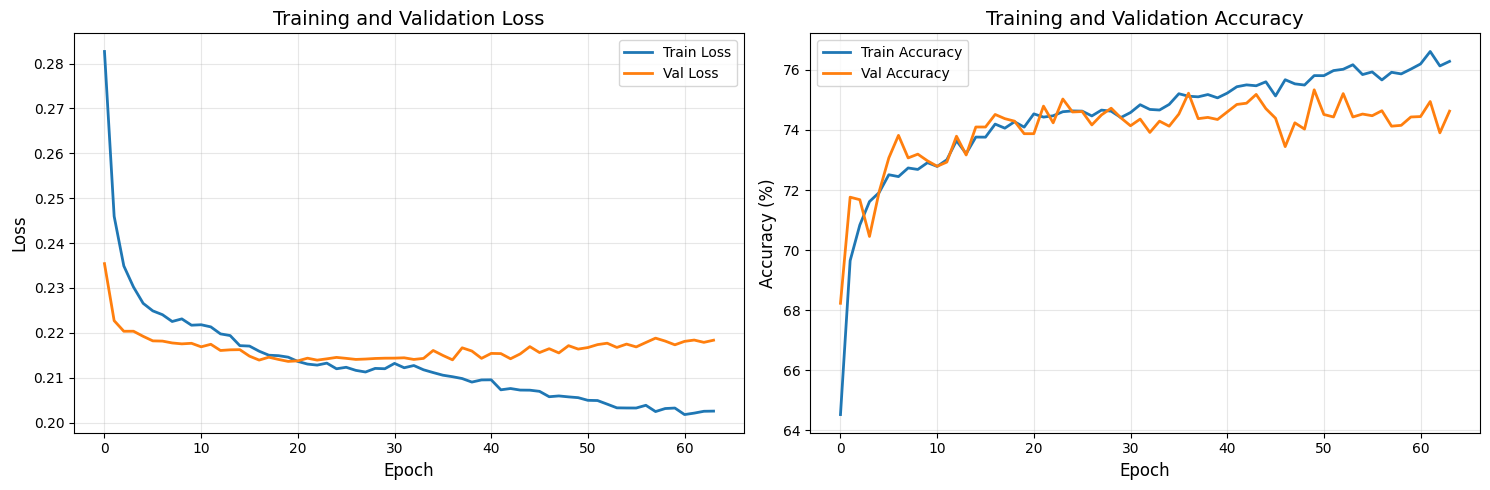

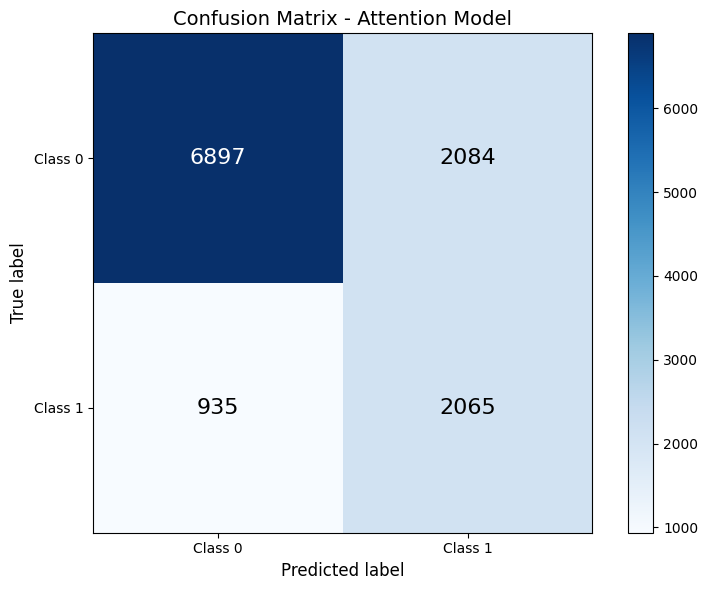


FEATURE ATTENTION ANALYSIS

Top 15 features by Attention Weight:
                  feature  attention_weight
4                    arpu          0.820930
23      cm_over_plan_flux          0.687540
29              bd_flux_m          0.641539
8        cm_tot_bill_dura          0.582361
42          if_nulim_prod          0.551879
78        hi_flux_usr_lbl          0.545004
53             game_cnt_m          0.538147
57     if_high_games_cust          0.534571
56         fashion_time_m          0.534311
7       l3m_avg_bill_dura          0.510486
20  cm_base_plan_flux_use          0.496473
19      cm_base_plan_flux          0.491937
52           travel_cnt_m          0.478734
41               grp_cnts          0.475950
62         gm_ngt_use_dur          0.468159


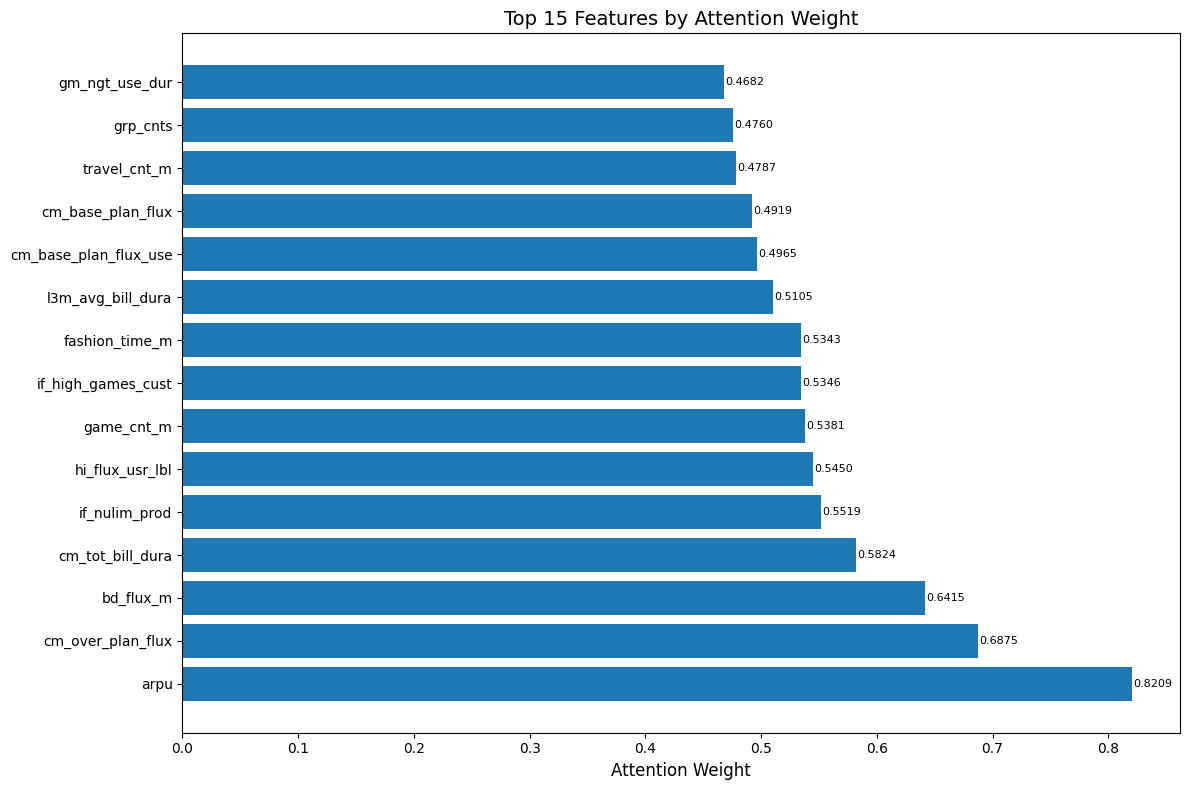


COMPARISON: Attention Model vs Random Forest

              Metric Random Forest  Attention Model
           Accuracy         0.797         0.748018
Precision (Class 0)          0.82         0.880618
Precision (Class 1)          0.68         0.497710
   Recall (Class 0)          0.94         0.767955
   Recall (Class 1)          0.36         0.688333
       F1 (Class 0)          0.87         0.820437
       F1 (Class 1)          0.47         0.577703
            ROC-AUC             -         0.803894

Key Improvements:
  • Recall on Class 1 (minority): 0.360 → 0.688 (+91.2%)
  • F1-Score on Class 1: 0.470 → 0.578 (+22.9%)
  • ROC-AUC Score: 0.8039


In [8]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, roc_auc_score
import matplotlib.pyplot as plt
import pandas as pd

# Custom Dataset
class TabularDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.FloatTensor(X)
        if hasattr(y, 'values'):
            y = y.values
        self.y = torch.LongTensor(y)
    
    def __len__(self):
        return len(self.X)
    
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

# Simpler Attention Model
class AttentionClassifier(nn.Module):
    def __init__(self, input_dim, hidden_dim=256, dropout=0.4):
        super(AttentionClassifier, self).__init__()
        
        self.input_dim = input_dim
        
        # Input processing
        self.input_bn = nn.BatchNorm1d(input_dim)
        
        # Feature-wise transformation
        self.feature_transform = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout)
        )
        
        # Self-attention mechanism
        self.query = nn.Linear(hidden_dim, hidden_dim)
        self.key = nn.Linear(hidden_dim, hidden_dim)
        self.value = nn.Linear(hidden_dim, hidden_dim)
        self.scale = np.sqrt(hidden_dim)
        
        # Feature attention (for interpretability)
        self.feature_attention = nn.Sequential(
            nn.Linear(input_dim, hidden_dim // 2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim // 2, input_dim),
            nn.Sigmoid()
        )
        
        # Deep network
        self.network = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.BatchNorm1d(hidden_dim // 2),
            nn.ReLU(),
            nn.Dropout(dropout),
            
            nn.Linear(hidden_dim // 2, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(dropout),
            
            nn.Linear(128, 2)
        )
        
    def forward(self, x):
        # Batch normalization on input
        x_norm = self.input_bn(x)
        
        # Feature attention
        feat_attn = self.feature_attention(x_norm)
        x_attended = x_norm * feat_attn
        
        # Feature transformation
        x_hidden = self.feature_transform(x_attended)
        
        # Self-attention
        Q = self.query(x_hidden).unsqueeze(1)  # (batch, 1, hidden)
        K = self.key(x_hidden).unsqueeze(1)    # (batch, 1, hidden)
        V = self.value(x_hidden).unsqueeze(1)  # (batch, 1, hidden)
        
        attention_scores = torch.matmul(Q, K.transpose(-2, -1)) / self.scale
        attention_weights = F.softmax(attention_scores, dim=-1)
        attended = torch.matmul(attention_weights, V).squeeze(1)
        
        # Residual connection
        x_combined = x_hidden + attended
        
        # Final prediction
        out = self.network(x_combined)
        
        return out, feat_attn

# Focal Loss with adjustable parameters
class FocalLoss(nn.Module):
    def __init__(self, alpha=None, gamma=1.0, reduction='mean'):
        super(FocalLoss, self).__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.reduction = reduction
    
    def forward(self, inputs, targets):
        ce_loss = F.cross_entropy(inputs, targets, reduction='none', weight=self.alpha)
        pt = torch.exp(-ce_loss)
        focal_loss = ((1 - pt) ** self.gamma) * ce_loss
        
        if self.reduction == 'mean':
            return focal_loss.mean()
        return focal_loss

def train_epoch(model, train_loader, criterion, optimizer, device):
    model.train()
    total_loss = 0
    correct = 0
    total = 0
    
    for inputs, targets in train_loader:
        inputs, targets = inputs.to(device), targets.to(device)
        
        optimizer.zero_grad()
        outputs, _ = model(inputs)
        loss = criterion(outputs, targets)
        
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        
        total_loss += loss.item()
        _, predicted = outputs.max(1)
        total += targets.size(0)
        correct += predicted.eq(targets).sum().item()
    
    return total_loss / len(train_loader), 100. * correct / total

def validate(model, val_loader, criterion, device):
    model.eval()
    total_loss = 0
    correct = 0
    total = 0
    all_preds = []
    all_targets = []
    all_probs = []
    
    with torch.no_grad():
        for inputs, targets in val_loader:
            inputs, targets = inputs.to(device), targets.to(device)
            
            outputs, _ = model(inputs)
            loss = criterion(outputs, targets)
            
            total_loss += loss.item()
            probs = F.softmax(outputs, dim=1)
            _, predicted = outputs.max(1)
            total += targets.size(0)
            correct += predicted.eq(targets).sum().item()
            
            all_preds.extend(predicted.cpu().numpy())
            all_targets.extend(targets.cpu().numpy())
            all_probs.extend(probs[:, 1].cpu().numpy())
    
    return total_loss / len(val_loader), 100. * correct / total, all_preds, all_targets, all_probs

# Prepare data
print("Preparing data...")
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

if hasattr(y_train, 'values'):
    y_train_np = y_train.values
else:
    y_train_np = y_train

if hasattr(y_test, 'values'):
    y_test_np = y_test.values
else:
    y_test_np = y_test

# Split training data for validation
X_train_split, X_val_split, y_train_split, y_val_split = train_test_split(
    X_train_scaled, y_train_np, test_size=0.15, random_state=42, stratify=y_train_np
)

# Create datasets
train_dataset = TabularDataset(X_train_split, y_train_split)
val_dataset = TabularDataset(X_val_split, y_val_split)
test_dataset = TabularDataset(X_test_scaled, y_test_np)

# Calculate class weights - LESS AGGRESSIVE
class_counts = np.bincount(y_train_split)
# Use square root to reduce the imbalance impact
class_weights = np.sqrt(1.0 / class_counts)
class_weights = class_weights / class_weights.sum() * 2  # Normalize
print(f"Class distribution in training: {class_counts}")
print(f"Class weights: {class_weights}")

# Create data loaders - NO WEIGHTED SAMPLING
batch_size = 512  # Larger batch size for stability
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

# Initialize model
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

input_dim = X_train_scaled.shape[1]
model = AttentionClassifier(
    input_dim=input_dim,
    hidden_dim=256,
    dropout=0.4
).to(device)

print(f"\nModel Architecture:")
print(model)
print(f"\nTotal parameters: {sum(p.numel() for p in model.parameters()):,}")

# Loss function with MODERATE class weights and LOWER gamma
alpha = torch.FloatTensor(class_weights).to(device)
criterion = FocalLoss(alpha=alpha, gamma=1.0)  # Reduced from 2.0

# Optimizer with moderate learning rate
optimizer = torch.optim.AdamW(model.parameters(), lr=0.0005, weight_decay=0.001)

# Cosine annealing scheduler for smooth learning rate decay
scheduler = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(
    optimizer, T_0=10, T_mult=2, eta_min=1e-6
)

# Training loop
num_epochs = 100
best_val_f1 = 0  # Track F1 score instead of loss
patience = 20
patience_counter = 0
train_losses = []
val_losses = []
train_accs = []
val_accs = []

print("\nStarting training...")
for epoch in range(num_epochs):
    train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, device)
    val_loss, val_acc, val_preds, val_targets, _ = validate(model, val_loader, criterion, device)
    
    # Calculate F1 score for minority class
    from sklearn.metrics import f1_score
    val_f1 = f1_score(val_targets, val_preds, average='macro')  # Use macro F1
    
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accs.append(train_acc)
    val_accs.append(val_acc)
    
    scheduler.step()
    
    print(f'Epoch [{epoch+1}/{num_epochs}] '
          f'Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}% | '
          f'Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.2f}%, Val F1: {val_f1:.4f}')
    
    # Early stopping based on F1 score
    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        patience_counter = 0
        torch.save(model.state_dict(), 'best_attention_model.pth')
        print(f'  --> Saved best model (Val F1: {val_f1:.4f})')
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print(f'\nEarly stopping at epoch {epoch+1}')
            break

# Load best model
model.load_state_dict(torch.load('best_attention_model.pth'))

# Evaluate on test set
print("\n" + "="*60)
print("FINAL EVALUATION ON TEST SET")
print("="*60)

test_loss, test_acc, y_pred, y_true, y_probs = validate(model, test_loader, criterion, device)

print(f"\nTest Accuracy: {test_acc:.2f}%")
print(f"Test Loss: {test_loss:.4f}")

# Classification report
print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=['Class 0', 'Class 1']))

# ROC-AUC
roc_auc = roc_auc_score(y_true, y_probs)
print(f"\nROC-AUC Score: {roc_auc:.4f}")

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)
print("\nConfusion Matrix:")
print(cm)

# Plot training history
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].plot(train_losses, label='Train Loss', linewidth=2)
axes[0].plot(val_losses, label='Val Loss', linewidth=2)
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('Loss', fontsize=12)
axes[0].set_title('Training and Validation Loss', fontsize=14)
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(train_accs, label='Train Accuracy', linewidth=2)
axes[1].plot(val_accs, label='Val Accuracy', linewidth=2)
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('Accuracy (%)', fontsize=12)
axes[1].set_title('Training and Validation Accuracy', fontsize=14)
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Visualize confusion matrix
plt.figure(figsize=(8, 6))
plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
plt.title('Confusion Matrix - Attention Model', fontsize=14)
plt.colorbar()
tick_marks = np.arange(2)
plt.xticks(tick_marks, ['Class 0', 'Class 1'])
plt.yticks(tick_marks, ['Class 0', 'Class 1'])

thresh = cm.max() / 2.
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, format(cm[i, j], 'd'),
                ha="center", va="center",
                color="white" if cm[i, j] > thresh else "black",
                fontsize=16)

plt.ylabel('True label', fontsize=12)
plt.xlabel('Predicted label', fontsize=12)
plt.tight_layout()
plt.show()

# Extract feature attention weights
print("\n" + "="*60)
print("FEATURE ATTENTION ANALYSIS")
print("="*60)

model.eval()
attention_weights_list = []

with torch.no_grad():
    for inputs, _ in test_loader:
        inputs = inputs.to(device)
        _, attn_weights = model(inputs)
        attention_weights_list.append(attn_weights.cpu().numpy())

all_attention_weights = np.concatenate(attention_weights_list, axis=0)
avg_attention = all_attention_weights.mean(axis=0)

feature_attention_df = pd.DataFrame({
    'feature': X_filled.columns,
    'attention_weight': avg_attention
}).sort_values('attention_weight', ascending=False)

print("\nTop 15 features by Attention Weight:")
print(feature_attention_df.head(15))

# Visualize feature attention
plt.figure(figsize=(12, 8))
top_attention = feature_attention_df.head(15)
bars = plt.barh(range(len(top_attention)), top_attention['attention_weight'])
plt.yticks(range(len(top_attention)), top_attention['feature'])
plt.xlabel('Attention Weight', fontsize=12)
plt.title('Top 15 Features by Attention Weight', fontsize=14)

for i, (bar, val) in enumerate(zip(bars, top_attention['attention_weight'])):
    plt.text(val + 0.001, i, f'{val:.4f}', va='center', ha='left', fontsize=8)

plt.tight_layout()
plt.show()

# Compare with Random Forest
print("\n" + "="*60)
print("COMPARISON: Attention Model vs Random Forest")
print("="*60)

from sklearn.metrics import precision_recall_fscore_support

attn_precision, attn_recall, attn_f1, _ = precision_recall_fscore_support(
    y_true, y_pred, average=None
)

rf_precision = [0.82, 0.68]
rf_recall = [0.94, 0.36]
rf_f1 = [0.87, 0.47]
rf_accuracy = 0.797

comparison_df = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision (Class 0)', 'Precision (Class 1)', 
               'Recall (Class 0)', 'Recall (Class 1)', 
               'F1 (Class 0)', 'F1 (Class 1)', 'ROC-AUC'],
    'Random Forest': [rf_accuracy, rf_precision[0], rf_precision[1], 
                      rf_recall[0], rf_recall[1], rf_f1[0], rf_f1[1], '-'],
    'Attention Model': [test_acc/100, attn_precision[0], attn_precision[1],
                        attn_recall[0], attn_recall[1], attn_f1[0], attn_f1[1], roc_auc]
})

print("\n", comparison_df.to_string(index=False))

print("\nKey Improvements:")
improvement_recall = ((attn_recall[1]/rf_recall[1] - 1) * 100) if rf_recall[1] > 0 else 0
improvement_f1 = ((attn_f1[1]/rf_f1[1] - 1) * 100) if rf_f1[1] > 0 else 0
print(f"  • Recall on Class 1 (minority): {rf_recall[1]:.3f} → {attn_recall[1]:.3f} "
      f"({improvement_recall:+.1f}%)")
print(f"  • F1-Score on Class 1: {rf_f1[1]:.3f} → {attn_f1[1]:.3f} "
      f"({improvement_f1:+.1f}%)")
print(f"  • ROC-AUC Score: {roc_auc:.4f}")